# Peligro por Subsidencia 

Después del proceso realizado en la supercomputadora Miztli, tenemos como resultado un mapa de velocidades, la serie obtenida del proceso realizado para la zona de La Laguna que abarca 4 municipios y 2 estados.

Se cargaran las bibliotecas a usar:

In [47]:
#bibliotecas para lectura de información
library(sf) #uso de información vectorial
library(terra) #uso de información raster
library(ggplot2) #gráficos
library(ggspatial) #gráficos para norte y escala
library(moments) #estadigráfos
library(DT) #formato de tabla

#biblioteca para desplegar en mapa


Se realiza la lectura de la imagen, se da la estructura para que se pueda personalizar la ruta de la información.

```r
dir <- "ruta_del_directorio"
archivo <- "Nombre_del_archivo.csv"
dir_data <- file.path(dir, archivo)
```
Se usa el comando `getwd()` para observar el directorio donde ejecutamos el notebook.

In [2]:
dir_r <- "./subsidencia"
archivo_r <- "TorreonSenDT12_2014_2023_geoVelocity.tiff"
dir_data_r <- file.path(dir_r, archivo_r)

Procedemos a cargar la variable en nuestro entorno de trabajo para poderlo desplegar en el mapa.

In [3]:
vel_sub <- rast(dir_data_r)

Propiedades del mapa de velocidades (ráster).

- dimensiones
- resolución
- extensión
- sistema de coordenadas
- tipo de formato

In [4]:
print(vel_sub[[1]])

class       : SpatRaster 
dimensions  : 4513, 4523, 1  (nrow, ncol, nlyr)
resolution  : 0.0006729102, 0.0006283581  (x, y)
extent      : -104.6331, -101.5895, 23.95375, 26.78953  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source      : TorreonSenDT12_2014_2023_geoVelocity.tiff 
name        : TorreonSenDT12_2014_2023_geoVelocity 
min value   :                           -0.1343978 
max value   :                            0.0160646 


Resolución de mapa de velocidades en grados

In [ ]:
res(vel_sub)

## Análisis exploratorio de los datos de velocidad de subsidencia

Boxplot, donde se observa que los datos atípicos representan la velocidad de subsidencia

Warning message:
“[boxplot] taking a sample of 1e+05 cells”


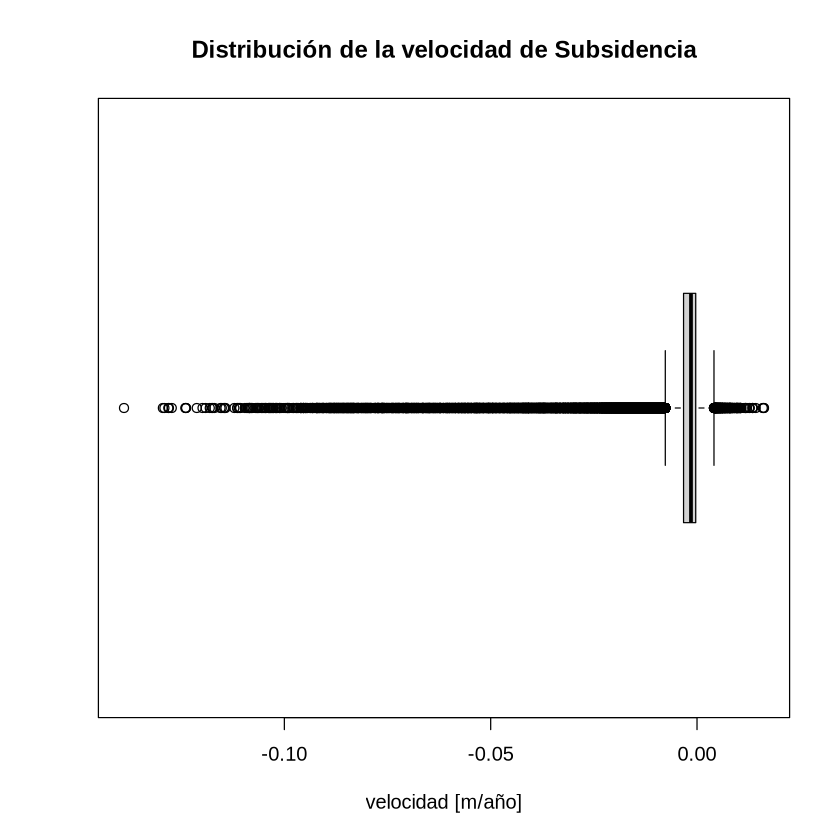

In [5]:
boxplot(vel_sub, horizontal = TRUE,
       main = "Distribución de la velocidad de Subsidencia",
       xlab = "velocidad [m/año]")

Warning message:
“[hist] a sample of 5% of the cells was used (of which 24% was NA)”


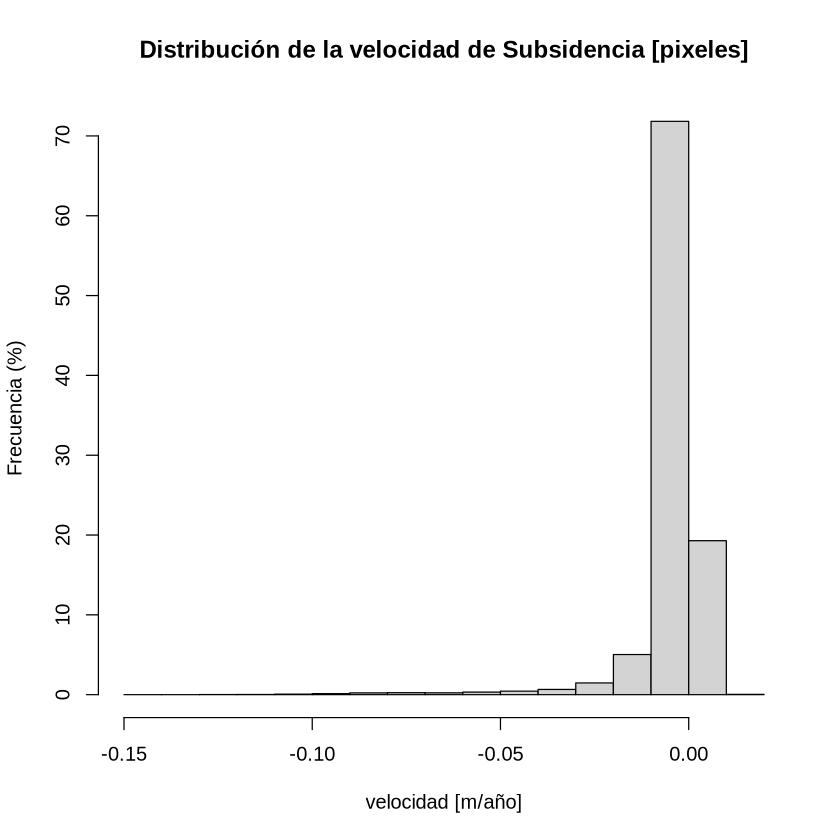

In [6]:
hist(vel_sub, prob = TRUE, breaks = 20, 
     xlab = "velocidad [m/año]", ylab = "Frecuencia (%)", 
     main = "Distribución de la velocidad de Subsidencia [pixeles]")

#cambia a codigo presiona "y"  
#cambio a texto presiona "m"

density(vel_sub,
       main = "Distribución de la velocidad de Subdidencia")

Cálculo de estadígrafos, se obtiene con el fin de realizar un análisis exploratorio del mapa de velocidades.

### Forma 1

Usando `global()` del paquete terra.

Nota: Se recomienda la Forma 2.

In [50]:
#Forma  1 calculo de estadisticos
#Se recomienda la forma 2
sub_mean <- global(vel_sub, fun="mean", na.rm=TRUE)
sub_max <- global(vel_sub, fun="max", na.rm=TRUE)
sub_min <- global(vel_sub, fun="min", na.rm=TRUE)
sub_sd <- global(vel_sub, fun="sd", na.rm=TRUE)

sub_estadisticos <- data.frame (
  Estadígrafo = c("Media", "Maximo", "minimo", "des estandar"),
  Valor = c(sub_mean[1,1], sub_max[1,1], sub_min[1,1], sub_sd[1,1])
)

sub_estadisticos

Estadígrafo,Valor
<chr>,<dbl>
Media,-0.01108233
Maximo,0.02195245
minimo,-0.15455741
des estandar,0.02111735


### Forma 2

Transformar el archivo ráster a un data frame, y sacar sus estadísticos. 
También se puede usar la librería `ggplot` para poder realizar las representaciones gráficas

In [7]:
#transformación de la información
vel_sub2 <- as.data.frame(vel_sub, xy = TRUE)
#omite los valores NA
vel_sub2 <- na.omit(vel_sub2)
str(vel_sub2)

'data.frame':	15562049 obs. of  3 variables:
 $ x                                   : num  -103 -103 -103 -103 -103 ...
 $ y                                   : num  26.8 26.8 26.8 26.8 26.8 ...
 $ TorreonSenDT12_2014_2023_geoVelocity: num  0.00236 0.00236 0.00236 0.00236 0.00236 ...


Estadísticos:

In [49]:
sub_median <- median(vel_sub2[,3])
sub_mean <- mean(vel_sub2[,3])
sub_min <- min(vel_sub2[,3])
sub_max <- max(vel_sub2[,3])
sub_q1 <- as.double(quantile(vel_sub2[,3],0.25))
sub_q3 <- as.double(quantile(vel_sub2[,3],0.75))
sub_sd <- sd(vel_sub2[,3])
sub_sim <- skewness(vel_sub2[,3])
sub_kur <- kurtosis(vel_sub2[,3])
sub_ran <- sub_max - sub_min

sub_estadisticos <- data.frame (
  Estadígrafo = c("Mediana","Media", "Mínimo", "Máximo", 
                  "Cuantil 1", "Cuantil 3"  ,"Desviación Estándar",
                 "Simetría", "Kurtosis", "Rango"),
  Valor = round(c(sub_median, sub_mean, sub_min, sub_max,
           sub_q1, sub_q3, sub_sd, sub_sim, sub_kur, sub_ran),4)
)

sub_estadisticos

Estadígrafo,Valor
<chr>,<dbl>
Mediana,-0.0015
Media,-0.0039
Mínimo,-0.1546
Máximo,0.0228
Cuantil 1,-0.0033
Cuantil 3,-0.0003
Desviación Estándar,0.0100
Simetría,-5.7517
Kurtosis,44.2322


Supuesto de normalidad, se observa que los valores que están debajo de la línea de normalidad representan a la subsidencia del terreno.
el gráfico se puede omitir.

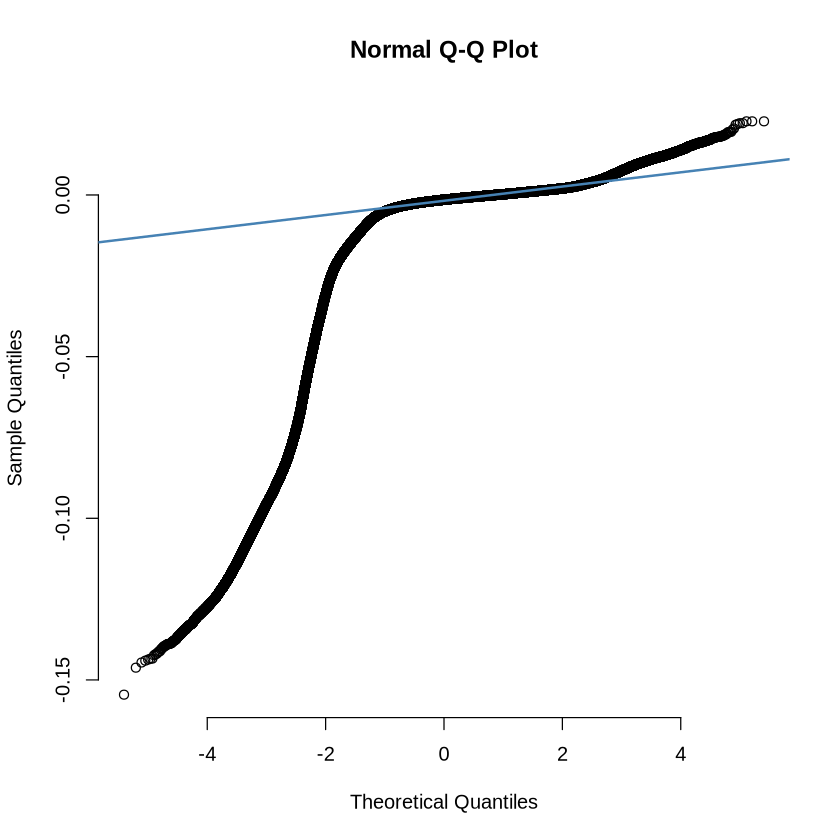

In [9]:
qqnorm(vel_sub2[,3], pch = 1, frame = FALSE)
qqline(vel_sub2[,3], col = "steelblue", lwd = 2)

### Mapas de subsidencia

Desplegamos una vista del mapa de velocidades de subsidencia.

#### Forma 1 con `plot()`

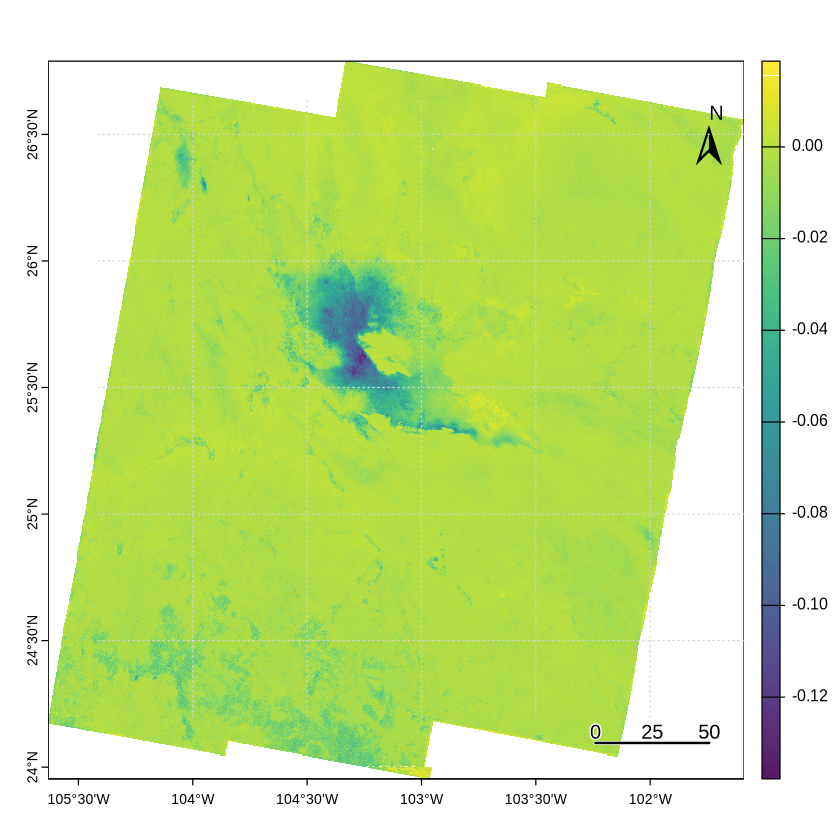

In [10]:
#forma tradicional
plot(vel_sub,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()
#contour(vel_sub, add=TRUE)

#### Forma 2 con `ggplot2`

Grafico con la libreria `ggplot2`

Warning message:
“Removed 4850250 rows containing missing values or values outside the scale range (`geom_raster()`).”


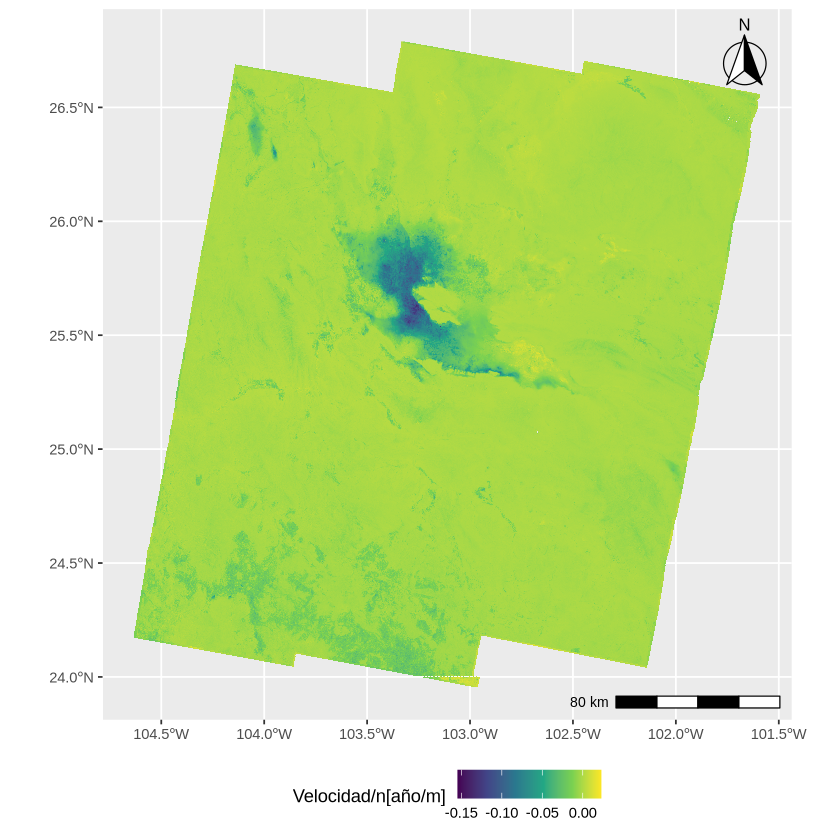

In [11]:
ggplot() +
  layer_spatial(vel_sub) +
  annotation_north_arrow(location = "tr", which_north = "true", style = north_arrow_fancy_orienteering) +
  annotation_scale(location = "br") +
  scale_fill_continuous(na.value = NA, type = "viridis") +
  labs(fill= "Velocidad/n[año/m]") +
  theme(legend.position = "bottom")

Usando la biblioteca ggplot2.

Las unidades del mapa de velocidades resultado del proceso en MintPy son en metros, se puede realizar la conversión a otras unidades por ejemplo: $raster*100=cm$

### Opción de extensión

La extensión del mapa de velocidades es extensa, se puede reducir.

Se requiere un vector con las coordenadas de los extremos deseados (E W S N) (xmin, xmax, ymin, ymax)

```{note}
si no se requiere se puede omitir esta sección
```

In [12]:
#vector para recorte opcional
ext<-c(-103.7,-102.45,25.2,26.1)

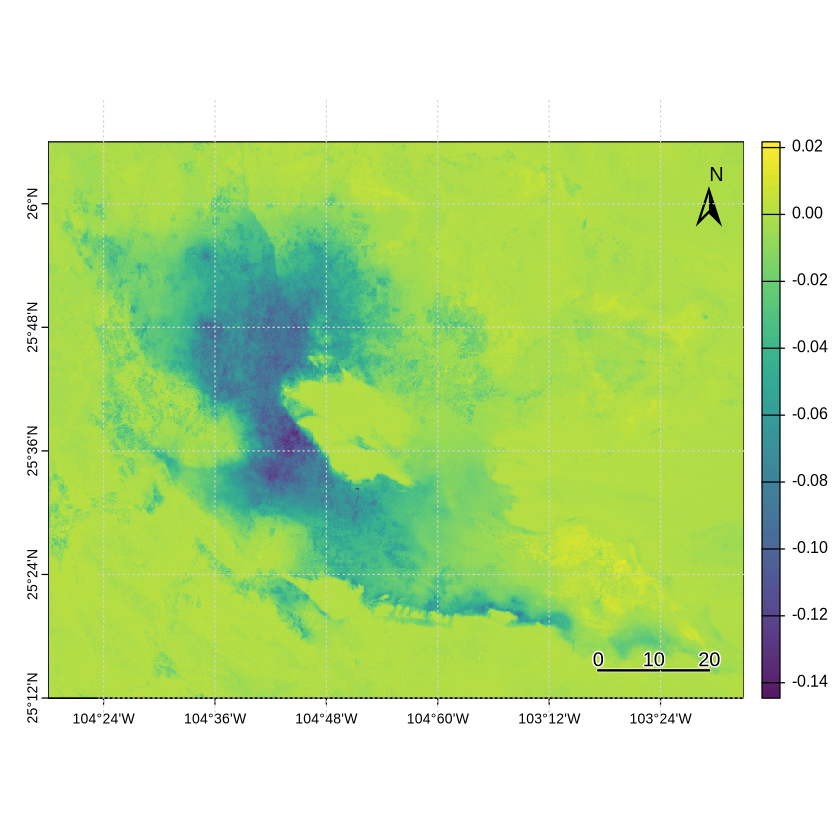

In [13]:
vel_sub <- crop(vel_sub, ext, snap= "near")
plot(vel_sub,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()

## Área afectada por la subsidencia

Para la obtención del área afectada por la subsidencia, en una primera instancia utilizamos el valor de la desviación estándar para realizar un corte y resaltar la zona de afectada por la subsidencia del terreno.

Se pude modificar el valor de forma manual modificando la variable `cort_sub`, el valor por defecto de la variable es la desviación estándar.

### Valor de corte de subsidencia

edición del valor

In [14]:
# variable a modicar opción manual
# descomenta o comenta para cambiar el valor
cort_sub <- -round(sub_sd,3)
# valor personalizado para obtener el area afectada por la subsidencia
#cort_sub <- -0.035
cort_sub

[1] -0.01

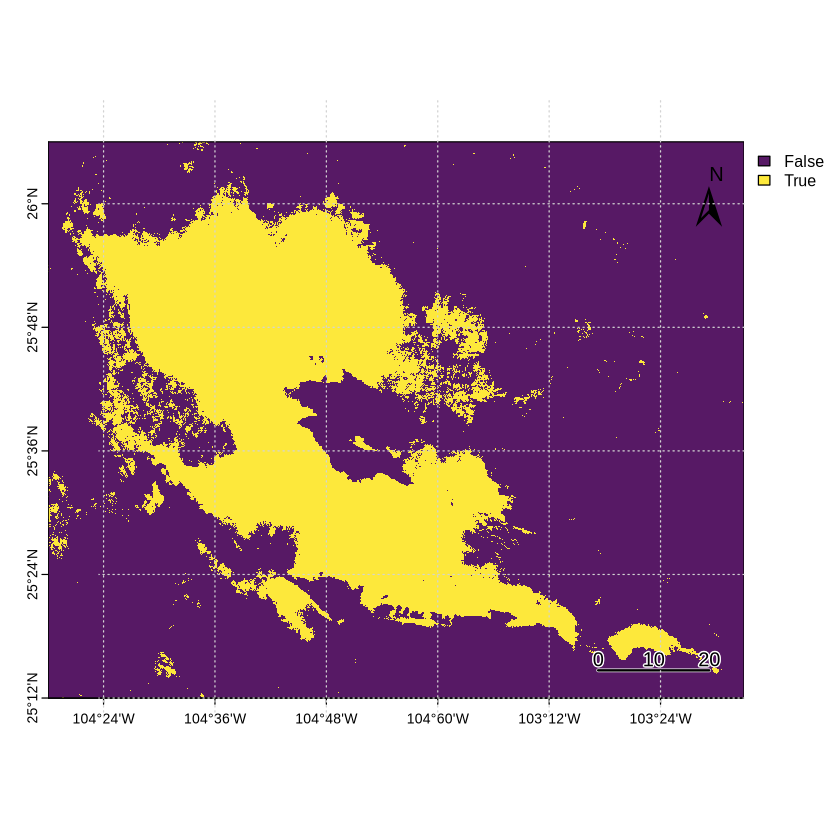

In [15]:
sub_des <- vel_sub <= cort_sub
plot(sub_des,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()

In [ ]:
class(sub_des)

Calcular el área de subsidencia, se transforma el raster en un vector

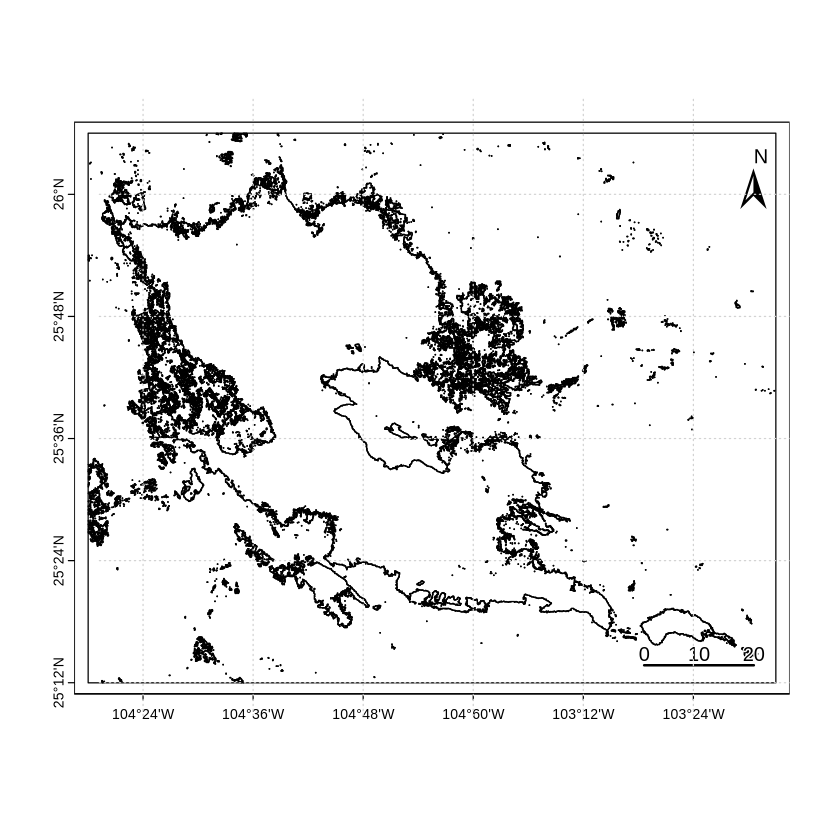

In [16]:
# transformar a poligono
area_sub <- as.polygons(sub_des) 
plot(area_sub,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()

Transformar la información de clase `SpatVector` de la libreria `terra` a un `data.frame` de la libreria `sf`, con el fin de calcular el área del poligono de subsidencia.

In [ ]:
# información vectorial obtenidos de la transformación
area_sub

In [17]:
#transformación de spatvetor a dataframe
area_sub <- st_as_sf(area_sub) 
class(area_sub)

[1] "sf"         "data.frame"

In [18]:
# calculo del area y su transformacion a km cuadrados
area_sub$area_km2 <- st_area(area_sub) / 10^6
# transformacion a data frame por un error no identificado
area_sub1 <- as.data.frame(area_sub)

Área afectada por la subsidencia al corte de

```{note}
El campo de valor entero 1 de la columna uno pertenece al área de subsidencia
```

In [19]:
cort_sub #valor de corte
area_sub1[c(1,3)]

[1] -0.01

,TorreonSenDT12_2014_2023_geoVelocity,area_km2
,<int>,<[m^2]>
1,0,9156.317 [m^2]
2,1,3384.721 [m^2]


In [ ]:
names(area_sub1)

Obtención del valor único de la subsidencia, la unidad es en $km^2$

In [20]:
area_s <- area_sub1[2,3] #filtro para obtener el area
area_s #area de subsidencia

3384.721 [m^2]

Mapa area de subsidencia

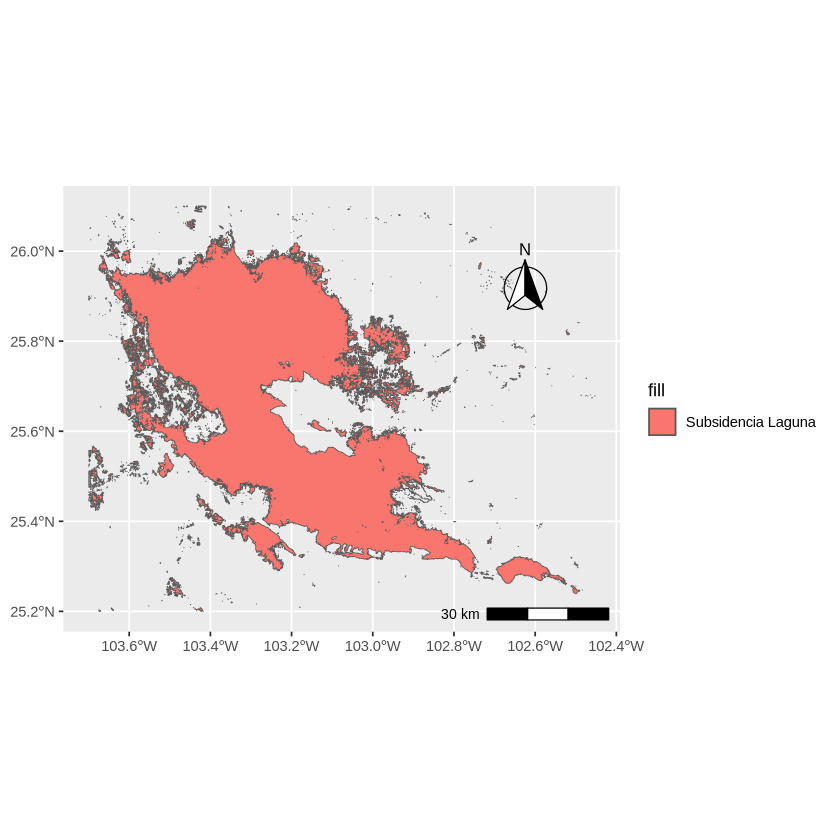

In [21]:
ggplot() +
  #annotation_map_tile(type = "osm") +
  layer_spatial(area_sub[2,], aes(fill="Subsidencia Laguna")) +
  annotation_scale(location = "br") +
  annotation_north_arrow(location = "tr", which_north = "true", 
                         pad_x = unit(0.5, "in"), pad_y =unit(0.5,"in"), 
                         style = north_arrow_fancy_orienteering) 

## Clasificación de las velocidades de subsidencia

### Forma automática

Del valor de corte, se clasificará los valores del mapa de velocidades en 5 categorías

In [22]:
# dejando los valores apartir del valor de corte

# Aplicar la máscara para establecer los valores a NA en el raster original
# se usara el poligono creado del area de corte
vel_sub_clas <- mask(vel_sub, area_sub[2,], updatevalue=NA)

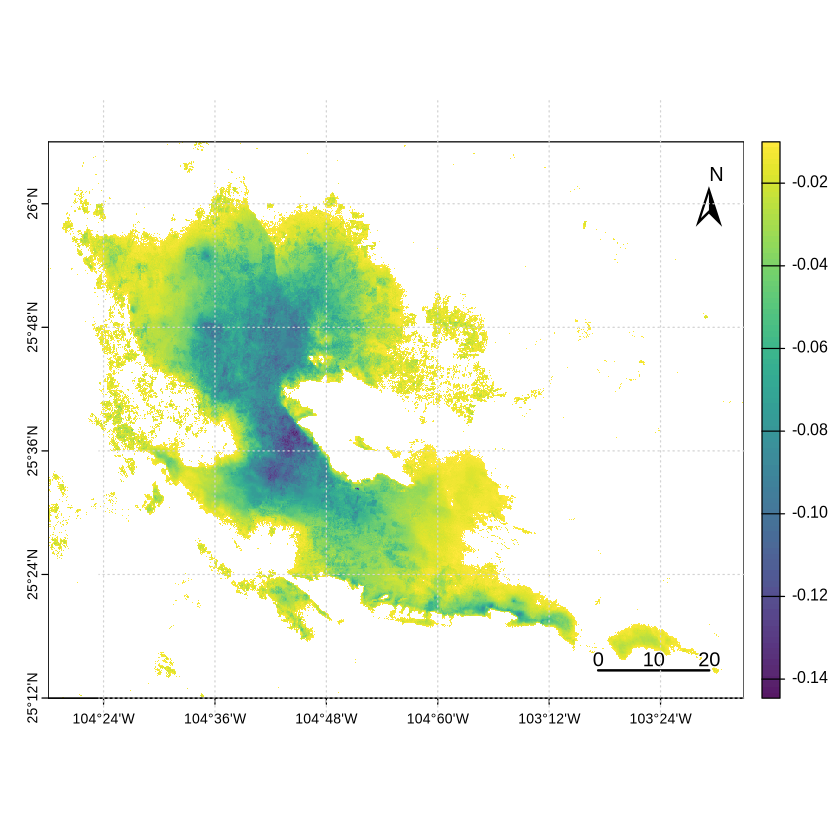

In [23]:
plot(vel_sub_clas,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()

#Cambiar a código para tener el mapa con ggplot y quitar `

```
ggplot() +
  layer_spatial(vel_sub_clas)+
  annotation_north_arrow(location = "tr", which_north = "true", style = north_arrow_fancy_orienteering) +
  annotation_scale(location = "br") +
  scale_fill_continuous(na.value = NA, type = "viridis") +
  labs(fill= "Velocidad/n[año/m]") +
  theme(legend.position = "bottom")
```

In [24]:
categorias<-cut(values(vel_sub_clas), breaks = 5, labels = c( 5, 4, 3, 2, 1), include.lowest = TRUE)

In [25]:
vel_sub_clas_cat <- setValues(vel_sub_clas,categorias )

In [26]:
vel_sub_clas_cat

class       : SpatRaster 
dimensions  : 1433, 1857, 1  (nrow, ncol, nlyr)
resolution  : 0.0006729102, 0.0006283581  (x, y)
extent      : -103.6998, -102.4502, 25.19979, 26.10022  (xmin, xmax, ymin, ymax)
coord. ref. : lon/lat WGS 84 (EPSG:4326) 
source(s)   : memory
varname     : TorreonSenDT12_2014_2023_geoVelocity 
categories  : label 
name        : TorreonSenDT12_2014_2023_geoVelocity 
min value   :                                    5 
max value   :                                    1 

Warning message:
“Removed 1942792 rows containing missing values or values outside the scale range (`geom_raster()`).”


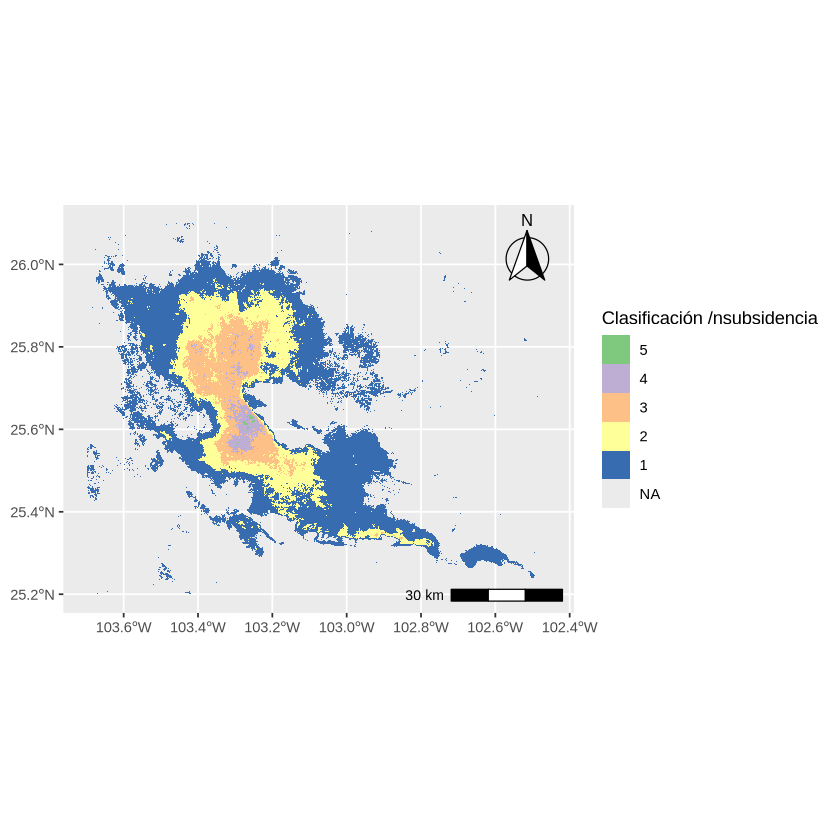

In [27]:
#mapa categorizado de la subsidencia

map1 <- ggplot() +
  layer_spatial(vel_sub_clas_cat) +
  annotation_north_arrow(location = "tr", which_north = "true", style = north_arrow_fancy_orienteering) +
  annotation_scale(location = "br") +
  scale_fill_brewer(na.value = NA, type = "qual") +
  labs(fill= "Clasificación /nsubsidencia")

map1

In [ ]:
#ggsave("myplot.pdf", map1, width = 20, height = 16, units = "cm")

#Cambiar a condigo para tener el mapa con plot y quitar `
```
plot(vel_sub_clas_cat,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()
```

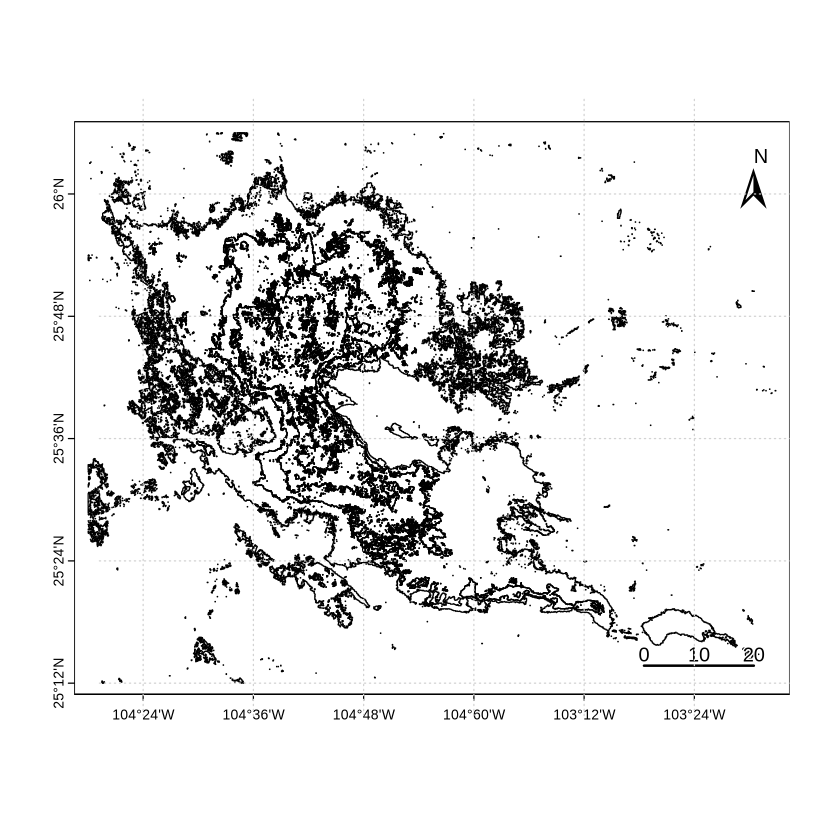

In [28]:
clas_sub_cat <- as.polygons(vel_sub_clas_cat) 
plot(clas_sub_cat,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()

In [ ]:
names(clas_sub_cat)

In [ ]:
values(clas_sub_cat)

#### Clasificación para el riesgo

Para evaluar el riesgo, se requiere la clasificación de la subsidencia, se colocará 1 al rango del valor máximo a la desviación estándar, que anteriormente se clasificó como NA, para que no se tenga errores al momento de multiplicar el resultado con otro raster

Para extraer lo datos de las categorías sigue los pasos:
- obtención de los rangos de las categorías en un tipo de dato factor
- trasformar la información de factor a vector
- eliminar los caracteres que representan los intervalos
- se separan los números separados por comas
- guardar cada valor separado en un vector

In [29]:
#obtención de los intervalos de corte calculados de forma autónoma
categoria_data <- cut(values(vel_sub_clas), breaks = 5, include.lowest = TRUE)

In [30]:
vec_data <- as.vector(na.omit((unique(categoria_data))))
vec_data

[1] "(-0.0389,-0.00986]" "(-0.0678,-0.0389]"  "(-0.0967,-0.0678]" 
[4] "(-0.126,-0.0967]"   "[-0.155,-0.126]"

In [31]:
#
vec_data <- gsub("[//(//)]", "", vec_data)
vec_data <- gsub("[//[//)]", "", vec_data)
vec_data <- gsub("]$", "", vec_data)
vec_data

[1] "-0.0389,-0.00986" "-0.0678,-0.0389"  "-0.0967,-0.0678"  "-0.126,-0.0967"  
[5] "-0.155,-0.126"

In [32]:
# Create an empty numeric vector to store the extracted values
num_cat <- numeric()

# Iterate through each element in the 'v' vector
for (i in 1:length(vec_data)) {
  # Split the current element into two strings based on the comma
  split_values <- strsplit(vec_data[i], ",")

  # Convert the split values to numeric and append them to the 'numeric_values' vector
  num_cat <- c(num_cat, as.numeric(split_values[[1]]))
}

# Print the extracted numeric values
print(num_cat)

 [1] -0.03890 -0.00986 -0.06780 -0.03890 -0.09670 -0.06780 -0.12600 -0.09670
 [9] -0.15500 -0.12600


In [33]:
#
m1 <- -round(sub_sd,3)
m2 <- num_cat[4]
m3 <- num_cat[6]
m4 <- num_cat[8]
m5 <- num_cat[10]

In [34]:
m_reclas <- c(m1, sub_max, 1, 
              m2, m1, 1, 
              m3, m2, 2, 
              m4, m3, 3, 
              m5, m4, 4, 
              sub_min, m5, 5)
tabla_reclas <- matrix(m_reclas, ncol=3, byrow=TRUE)
tabla_reclas

-0.0100000,0.02278254,1
-0.0389000,-0.01000000,1
-0.0678000,-0.03890000,2
-0.0967000,-0.06780000,3
-0.1260000,-0.09670000,4
-0.1545574,-0.12600000,5


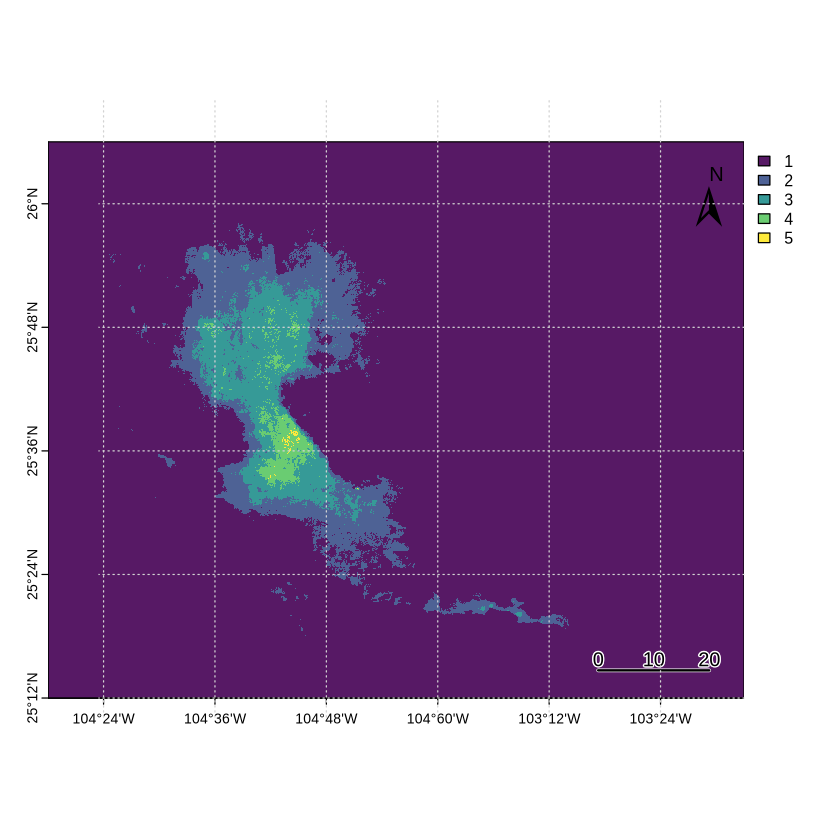

In [35]:
# clas_sub_r representa la clasificación realizada
# para la evalucion del riesgo
clas_sub_r <- classify(vel_sub, tabla_reclas)
plot(clas_sub_r,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()

### Forma manual

Se categoriza de forma manual el mapa de velocidades, con 5 clases muy bajo, bajo, moderado, alto y muy alto

donde las categorías son:

muy bajo = 1  
bajo = 2  
moderado = 3  
alto = 4 
muy alto 5

Para colocar los valores de categorías modificamos el código abajo

In [36]:
# Valores asignados automaticamente
tabla_reclas[1:5,]

-0.0100,0.02278254,1
-0.0389,-0.01000000,1
-0.0678,-0.03890000,2
-0.0967,-0.06780000,3
-0.1260,-0.09670000,4



#### Valores de clasificación manual

En la siguiente celda modifica los rangos de valores más convenientes

In [37]:
# Colocar valores de la clasificación en forma manual
m1 <- -0.01
m2 <- -0.035
m3 <- -0.06
m4 <- -0.085
m5 <- -0.11

Tabla de categorización de valores

In [38]:
m_reclas <- c(m1, sub_max, NA, 
              m2, m1, 1, 
              m3, m2, 2, 
              m4, m3, 3, 
              m5, m4, 4, 
              sub_min, m5, 5)
tabla_reclas <- matrix(m_reclas, ncol=3, byrow=TRUE)
tabla_reclas

-0.0100000,0.02278254,NA
-0.0350000,-0.01000000,1
-0.0600000,-0.03500000,2
-0.0850000,-0.06000000,3
-0.1100000,-0.08500000,4
-0.1545574,-0.11000000,5


In [39]:
vel_sub_clas_cat <- classify(vel_sub, tabla_reclas)

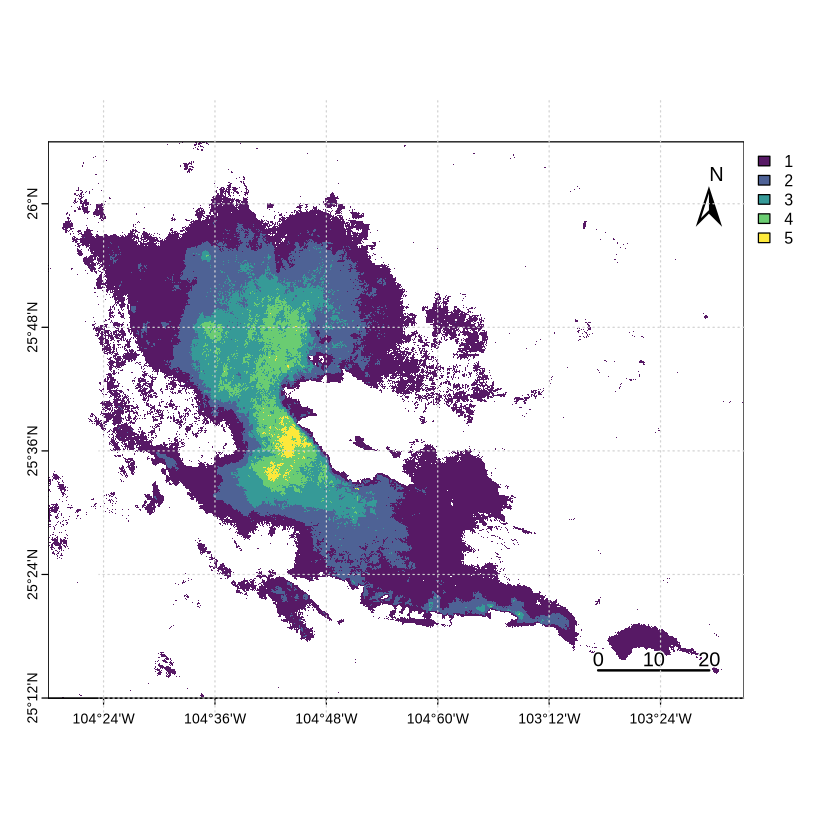

In [40]:
plot(vel_sub_clas_cat,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()

Warning message:
“Removed 1942792 rows containing missing values or values outside the scale range (`geom_raster()`).”


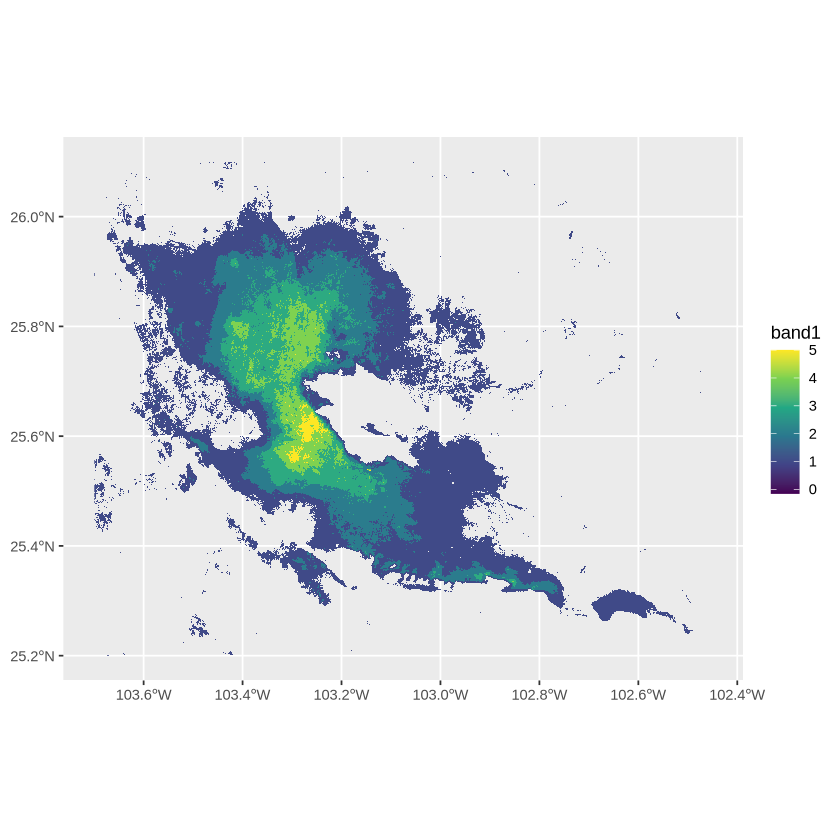

In [41]:
ggplot() +
  layer_spatial(vel_sub_clas_cat)+
  scale_fill_continuous(na.value = NA, type = "viridis")

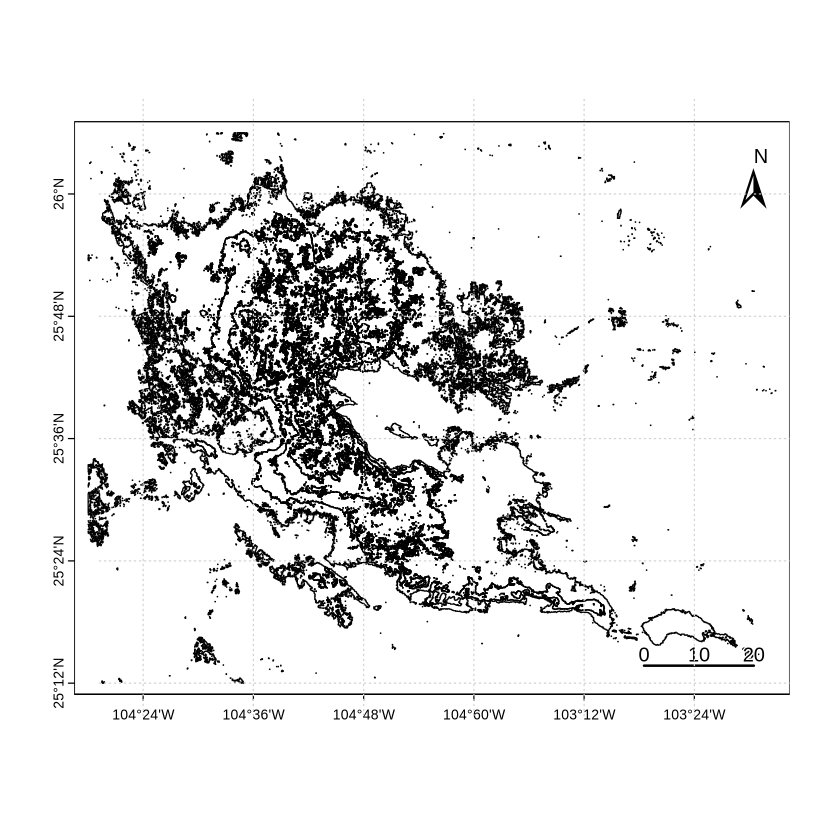

In [42]:
clas_sub_cat <- as.polygons(vel_sub_clas_cat) 
plot(clas_sub_cat,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()

#### Clasificación para riesgo

En esta parte se exportará para usarlo como insumo al evaluar el riesgo

In [43]:
m_reclas <- c(m1, sub_max, 1, 
              m2, m1, 1, 
              m3, m2, 2, 
              m4, m3, 3, 
              m5, m4, 4, 
              sub_min, m5, 5)
tabla_reclas <- matrix(m_reclas, ncol=3, byrow=TRUE)

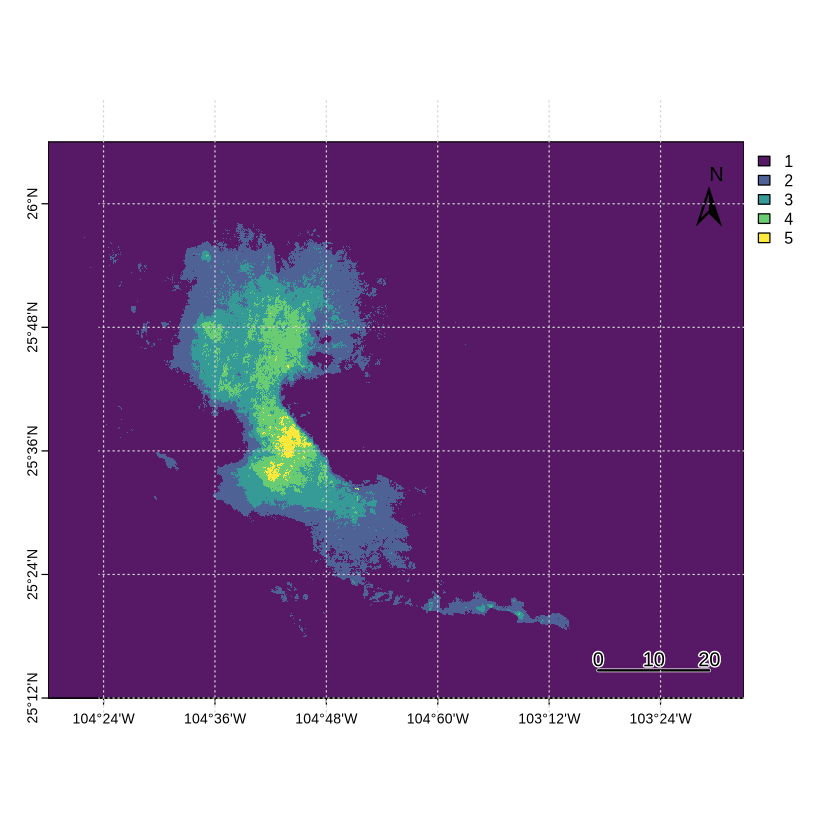

In [44]:
clas_sub_r <- classify(vel_sub, tabla_reclas)
plot(clas_sub_r,
    pax=list(side=1:2, retro=TRUE),
    alpha = 0.9)
north(type=2)
sbar(xy="bottomright", divs=3)
add_grid()

## Guardar información

In [ ]:
getwd()

In [ ]:
class(area_sub1)

In [ ]:
dir_save_shp <- "./resultados"
archivo_save_shp <- "Area_subsidencia_CDMX.shp"
dir_save_shp <- file.path(dir_save_shp, archivo_save_shp)

st_write(area_sub1, dir_save_shp)

In [ ]:
clas_sub_cat1 <- st_as_sf(clas_sub_cat) 

dir_save_shp <- "./resultados"
archivo_save_shp <- "Cat_subsidencia_CDMX.shp"
dir_save_shp <- file.path(dir_save_shp, archivo_save_shp)

st_write(clas_sub_cat1, dir_save_shp)

In [ ]:
dir_save_ras <- "./resultados"
archivo_save_ras <- "Cat_subsidencia_CDMX.tif"
dir_save_ras <- file.path(dir_save_ras, archivo_save_ras)

writeRaster(clas_sub_r, dir_save_ras, filetype = "GTiff", overwrite = TRUE)

In [ ]:
dir_save_ras <- "./resultados"
archivo_save_ras <- "subsidencia_crop_Laguna.tif"
dir_save_ras <- file.path(dir_save_ras, archivo_save_ras)

writeRaster(vel_sub, dir_save_ras, filetype = "GTiff", overwrite = TRUE)

## Mejoras

Trabajar en como clasificar el mapa de velocidades.

[Package ‘classInt’ documentacion](https://r-spatial.github.io/classInt/index.html)

[Package ‘classInt’ libro](https://cran.r-project.org/web/packages/classInt/classInt.pdf)

Despliegue de información en un mapa interactivo

In [45]:
library(leaflet)


In [ ]:
vel_sub[[1]]

HTML widgets cannot be represented in plain text (need html)
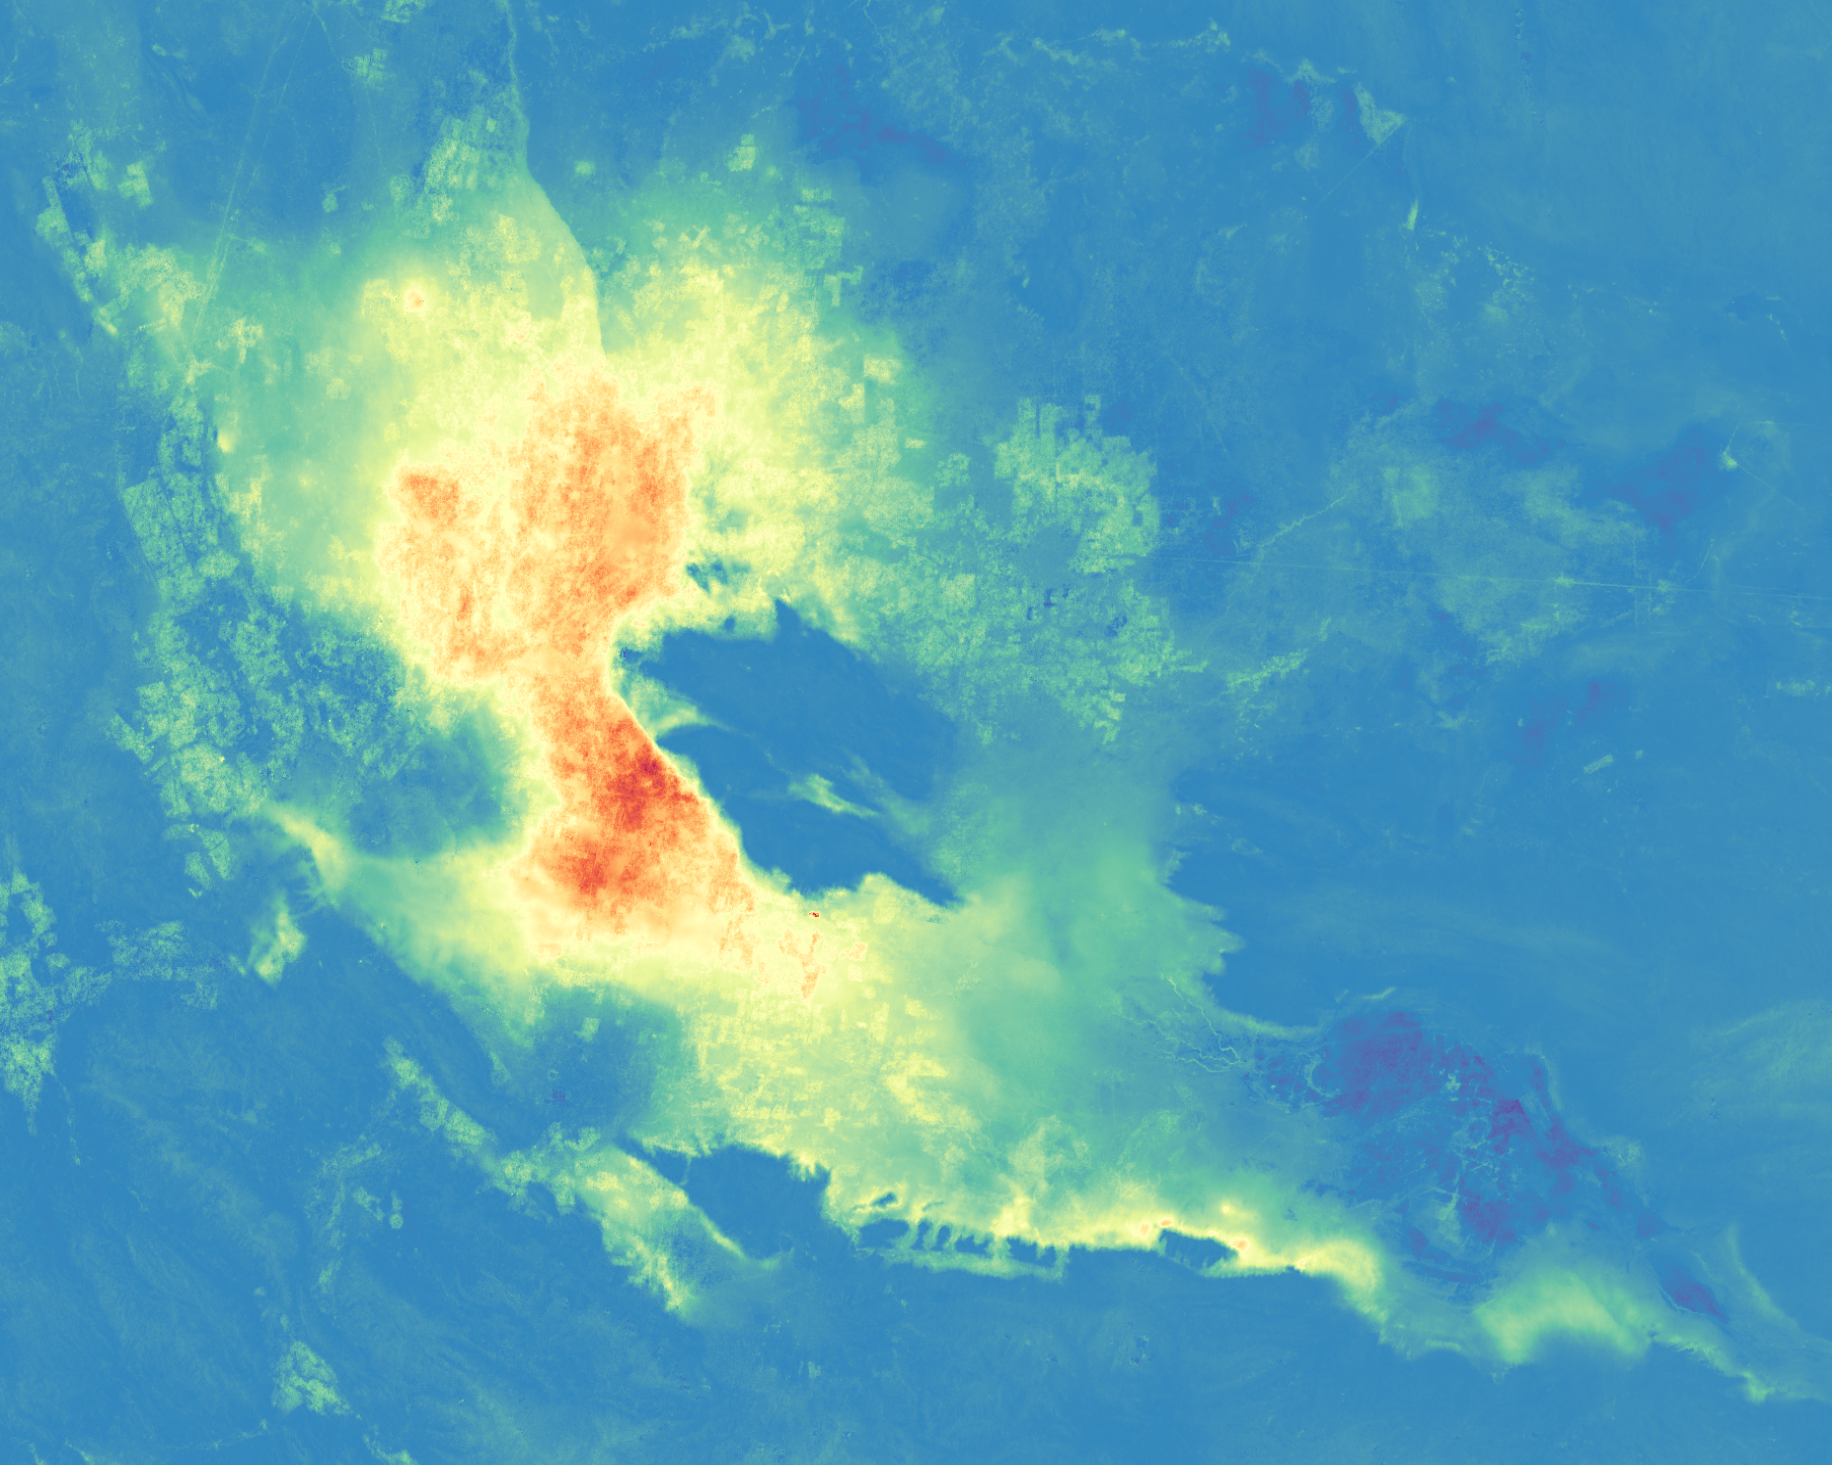

In [46]:
leaflet() %>% 
  addProviderTiles("OpenStreetMap") %>%
  addRasterImage(vel_sub, project = TRUE, group = "vel_sub",
                 layerId = "vel_sub",
                  opacity = 0.5)